In [115]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from nltk.tokenize import word_tokenize
import nltk
import matplotlib.pyplot as plt

In [116]:
document = """About the Job Readiness Program

What is the fee for the Job Market Accelerator Program 2026?
The program follows a subscription-based model where you pay Rs 2499/month.

What is the total duration of the program?
The total duration is 6 months. So the total cost becomes approximately Rs 14994.

What topics are covered in this program?
We cover the following modules:
Data Structures & Algorithms
Full Stack Development (MERN)
System Design Basics
SQL and Databases
Git and GitHub
AI Tools for Developers (ChatGPT, Copilot)
Resume & Portfolio Building
Mock Interviews
Job Application Strategies

Is Machine Learning or Deep Learning included?
No, this program focuses on software engineering roles. ML/DL is not covered in depth.

What kind of projects will we build?
You will build:
Full stack web apps
API-based systems
Real-world scalable mini-projects
Portfolio-ready projects

What if I miss a live session?
All sessions are recorded. You can watch them anytime.

Where can I find the schedule?
You will get access to a dashboard with a weekly roadmap and session calendar.

What is the duration of each session?
Each live session is approximately 1.5 to 2 hours.

What language will be used in teaching?
Hinglish (mix of Hindi and English).

Can non-CS students join this program?
Yes, beginners from any background can join.

Can I join the program late?
Yes, you can join anytime and access all past content.

Will I get access to previous recordings if I join late?
Yes, full access will be provided after payment.

Do I need to submit assignments?
Assignments are optional but strongly recommended. Solutions will be provided.

Will there be mock interviews?
Yes, mock interviews will be conducted with feedback.

How do I contact support?
You can email [support@jobaccelerator.com](mailto:support@jobaccelerator.com)

Payment & Subscription Queries

Where do I make the payment?
All payments are made through our official website.

Can I pay the full amount at once?
No, only monthly subscriptions are available.

What is the validity of one subscription?
Each payment is valid for 30 days from the date of purchase.

Is there a refund policy?
Yes, a 5-day refund policy is available after purchase.

I am outside India and facing payment issues. What should I do?
Please contact support via email for alternative payment options.

Post Enrollment Queries

How long will I have access to the content?
You will have access as long as your subscription is active.

What happens after the program ends?
If you complete all payments, you get 6 months extended access.

Will I get lifetime access?
No, due to the low pricing model.

Can I ask doubts after sessions?
Yes, doubt support is available via forms and scheduled calls.

Can I ask doubts from previous sessions?
Yes, you can ask doubts anytime.

Certificate & Placement Assistance

What is required to get a certificate?
You must:
Complete all payments
Attempt all assessments

Does this program guarantee a job?
No, we do not guarantee jobs.

What kind of placement assistance is provided?
We provide:
Resume reviews
LinkedIn optimization
Referral guidance
Job application tracking strategies
Interview preparation sessions

Will I get referrals?
Referrals are not guaranteed but guidance will be provided.

What roles can I target after this program?
You can target:
Software Engineer (SDE-1)
Frontend Developer
Backend Developer
Full Stack Developer

What is the expected salary range after completion?
Typically ranges from 4 LPA to 15 LPA depending on skills and performance.

Is prior coding experience required?
No, but basic computer knowledge helps.

How many hours should I dedicate daily?
At least 2–3 hours daily for best results.

Is this program suitable for college students?
Yes, especially 2nd, 3rd, and final year students.

Will this help in off-campus placements?
Yes, the program is designed specifically for off-campus job preparation.
"""


In [117]:
# Tokenization
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [118]:
# tokenize
tokens = word_tokenize(document.lower())

In [119]:
# build vocab
vocab = {'<unk>':0}

for token in Counter(tokens).keys():
  if token not in vocab:
    vocab[token] = len(vocab)

vocab

{'<unk>': 0,
 'about': 1,
 'the': 2,
 'job': 3,
 'readiness': 4,
 'program': 5,
 'what': 6,
 'is': 7,
 'fee': 8,
 'for': 9,
 'market': 10,
 'accelerator': 11,
 '2026': 12,
 '?': 13,
 'follows': 14,
 'a': 15,
 'subscription-based': 16,
 'model': 17,
 'where': 18,
 'you': 19,
 'pay': 20,
 'rs': 21,
 '2499/month': 22,
 '.': 23,
 'total': 24,
 'duration': 25,
 'of': 26,
 '6': 27,
 'months': 28,
 'so': 29,
 'cost': 30,
 'becomes': 31,
 'approximately': 32,
 '14994.': 33,
 'topics': 34,
 'are': 35,
 'covered': 36,
 'in': 37,
 'this': 38,
 'we': 39,
 'cover': 40,
 'following': 41,
 'modules': 42,
 ':': 43,
 'data': 44,
 'structures': 45,
 '&': 46,
 'algorithms': 47,
 'full': 48,
 'stack': 49,
 'development': 50,
 '(': 51,
 'mern': 52,
 ')': 53,
 'system': 54,
 'design': 55,
 'basics': 56,
 'sql': 57,
 'and': 58,
 'databases': 59,
 'git': 60,
 'github': 61,
 'ai': 62,
 'tools': 63,
 'developers': 64,
 'chatgpt': 65,
 ',': 66,
 'copilot': 67,
 'resume': 68,
 'portfolio': 69,
 'building': 70,
 '

In [120]:
input_sentences = document.split('\n')

In [121]:
input_numerical_sentences=[]
for sentence in input_sentences:
  input_numerical_sentences.append(text_to_indices(word_tokenize(sentence.lower()), vocab))



In [122]:

def text_to_indices(sentence, vocab):
    numerical_sentence=[]
    for token in sentence:
      if token in vocab:
        numerical_sentence.append(vocab[token])

      else:
        numerical_sentence.append(vocab['<unk>'])

    return numerical_sentence


In [123]:
len(input_numerical_sentences)

137

In [124]:
training_sequence=[]

for sentence in input_numerical_sentences:

  for i in range(1, len(sentence)):
    training_sequence.append(sentence[: i+1])

In [125]:
len(training_sequence)

631

In [126]:
len_list=[]


for x in training_sequence:
  len_list.append(len(x))


max(len_list)

17

In [127]:
padded_training_sequence=[]

for sequence in training_sequence:
  padded_training_sequence.append([0]*(max(len_list) - len(sequence)) + sequence)


In [128]:
padded_training_sequence = torch.tensor(padded_training_sequence, dtype = torch.long)

In [129]:
padded_training_sequence

tensor([[  0,   0,   0,  ...,   0,   1,   2],
        [  0,   0,   0,  ...,   1,   2,   3],
        [  0,   0,   0,  ...,   2,   3,   4],
        ...,
        [  0,   0,   0,  ...,   9, 290,   3],
        [  0,   0,   0,  ..., 290,   3, 247],
        [  0,   0,   0,  ...,   3, 247,  23]])

In [130]:
X = padded_training_sequence[:, :-1]
y = padded_training_sequence[:, -1]


In [131]:
class CustomDataset(Dataset):

  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return self.X.shape[0]

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [132]:
dataset = CustomDataset(X,y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [133]:
class LSTMModel(nn.Module):
  def __init__(self, vocab_size):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, 100)
    self.lstm = nn.LSTM(100,150, batch_first=True, dropout=0.2)
    self.fc = nn.Linear(150, vocab_size)
  def forward(self, x):
    embedded = self.embedding(x)
    intermediate_hidden_states, (final_hidden_state, final_cell_state) = self.lstm(embedded)
    output = self.fc(final_hidden_state.squeeze(0))

    return output

In [134]:
model = LSTMModel(len(vocab))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

LSTMModel(
  (embedding): Embedding(294, 100)
  (lstm): LSTM(100, 150, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=150, out_features=294, bias=True)
)

In [135]:
epochs=100
lrate=0.001
criterion=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lrate)

In [107]:
# for epoch in range(epochs):
#   total_loss=0

#   for batch_x, batch_y in dataloader:
#     batch_x, batch_y = batch_x.to(device), batch_y.to(device)

#     optimizer.zero_grad()

#     output=model(batch_x)

#     loss=criterion(output,batch_y)

#     loss.backward()
#     optimizer.step()

#     total_loss += loss.item()
#   print(f"Epoch: {epoch + 1}, Loss: {total_loss:.4f}")

Epoch: 1, Loss: 112.3756
Epoch: 2, Loss: 103.0932
Epoch: 3, Loss: 94.7548
Epoch: 4, Loss: 88.4723
Epoch: 5, Loss: 81.6362
Epoch: 6, Loss: 75.2100
Epoch: 7, Loss: 69.0385
Epoch: 8, Loss: 62.7786
Epoch: 9, Loss: 56.8149
Epoch: 10, Loss: 51.2515
Epoch: 11, Loss: 46.2687
Epoch: 12, Loss: 41.4042
Epoch: 13, Loss: 36.9890
Epoch: 14, Loss: 32.9827
Epoch: 15, Loss: 29.5348
Epoch: 16, Loss: 26.4462
Epoch: 17, Loss: 23.5834
Epoch: 18, Loss: 21.0971
Epoch: 19, Loss: 19.0851
Epoch: 20, Loss: 17.2774
Epoch: 21, Loss: 15.5305
Epoch: 22, Loss: 14.2868
Epoch: 23, Loss: 13.1826
Epoch: 24, Loss: 12.0651
Epoch: 25, Loss: 11.2044
Epoch: 26, Loss: 10.5133
Epoch: 27, Loss: 9.9644
Epoch: 28, Loss: 9.2997
Epoch: 29, Loss: 8.7210
Epoch: 30, Loss: 8.4264
Epoch: 31, Loss: 8.0506
Epoch: 32, Loss: 7.8010
Epoch: 33, Loss: 7.4483
Epoch: 34, Loss: 7.1796
Epoch: 35, Loss: 6.9780
Epoch: 36, Loss: 6.7153
Epoch: 37, Loss: 6.5050
Epoch: 38, Loss: 6.4150
Epoch: 39, Loss: 6.2378
Epoch: 40, Loss: 6.0165
Epoch: 41, Loss: 5.92

In [136]:
def prediction(model, vocab, text):

  device = next(model.parameters()).device

  tokenized_text = word_tokenize(text.lower())
  numerical_text = text_to_indices(tokenized_text, vocab)

  padded_text = torch.tensor(
      [0] * (16 - len(numerical_text)) + numerical_text,
      dtype=torch.long
  ).unsqueeze(0)

  padded_text = padded_text.to(device)

  output = model(padded_text)

  value, index = torch.max(output, dim=1)

  return text + " " + list(vocab.keys())[index]

In [141]:
# run this after training that happens below
import time

num_tokens = 10
input_text = "No, this program"

for i in range(num_tokens):
  output_text = prediction(model, vocab, input_text)
  print(output_text)
  input_text = output_text
  time.sleep(0.5)


No, this program focuses
No, this program focuses on
No, this program focuses on software
No, this program focuses on software engineering
No, this program focuses on software engineering roles
No, this program focuses on software engineering roles .
No, this program focuses on software engineering roles . ml/dl
No, this program focuses on software engineering roles . ml/dl is
No, this program focuses on software engineering roles . ml/dl is not
No, this program focuses on software engineering roles . ml/dl is not covered


In [142]:
dataloader1 = DataLoader(dataset, batch_size=32, shuffle=False)

In [143]:
def calculate_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_x, batch_y in dataloader1:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)


            outputs = model(batch_x)


            _, predicted = torch.max(outputs, dim=1)


            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

    accuracy = correct / total * 100
    return accuracy

# Compute accuracy
accuracy = calculate_accuracy(model, dataloader, device)
print(f"Model Accuracy: {accuracy:.2f}%")


Model Accuracy: 91.60%


In [140]:
model.train()

loss_history = []

for epoch in range(epochs):
    total_loss = 0
    for batch_x, batch_y in dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    loss_history.append(total_loss)
    print(f"Epoch: {epoch + 1}, Loss: {total_loss:.4f}")

Epoch: 1, Loss: 112.5476
Epoch: 2, Loss: 103.1071
Epoch: 3, Loss: 94.2665
Epoch: 4, Loss: 88.0254
Epoch: 5, Loss: 80.9412
Epoch: 6, Loss: 74.2460
Epoch: 7, Loss: 67.6256
Epoch: 8, Loss: 61.6212
Epoch: 9, Loss: 55.7691
Epoch: 10, Loss: 50.2470
Epoch: 11, Loss: 44.8520
Epoch: 12, Loss: 40.4769
Epoch: 13, Loss: 35.9748
Epoch: 14, Loss: 32.0088
Epoch: 15, Loss: 28.5899
Epoch: 16, Loss: 25.5174
Epoch: 17, Loss: 22.8435
Epoch: 18, Loss: 20.4153
Epoch: 19, Loss: 18.2111
Epoch: 20, Loss: 16.5726
Epoch: 21, Loss: 14.8911
Epoch: 22, Loss: 13.6847
Epoch: 23, Loss: 12.5482
Epoch: 24, Loss: 11.6502
Epoch: 25, Loss: 10.8100
Epoch: 26, Loss: 10.1553
Epoch: 27, Loss: 9.4700
Epoch: 28, Loss: 8.9144
Epoch: 29, Loss: 8.4440
Epoch: 30, Loss: 8.1450
Epoch: 31, Loss: 7.6920
Epoch: 32, Loss: 7.4893
Epoch: 33, Loss: 7.2467
Epoch: 34, Loss: 7.0297
Epoch: 35, Loss: 6.7328
Epoch: 36, Loss: 6.5267
Epoch: 37, Loss: 6.3989
Epoch: 38, Loss: 6.2413
Epoch: 39, Loss: 6.0504
Epoch: 40, Loss: 5.9706
Epoch: 41, Loss: 5.82

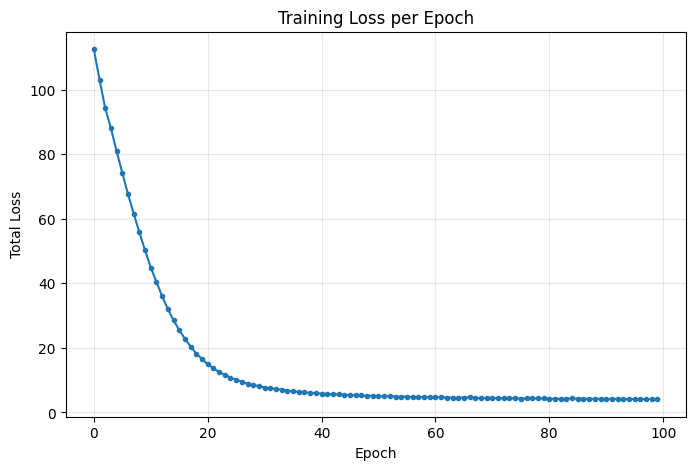

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history, marker='o', markersize=3)
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.grid(alpha=0.3)
plt.savefig("assets/training_loss.png", dpi=150, bbox_inches='tight')
plt.show()

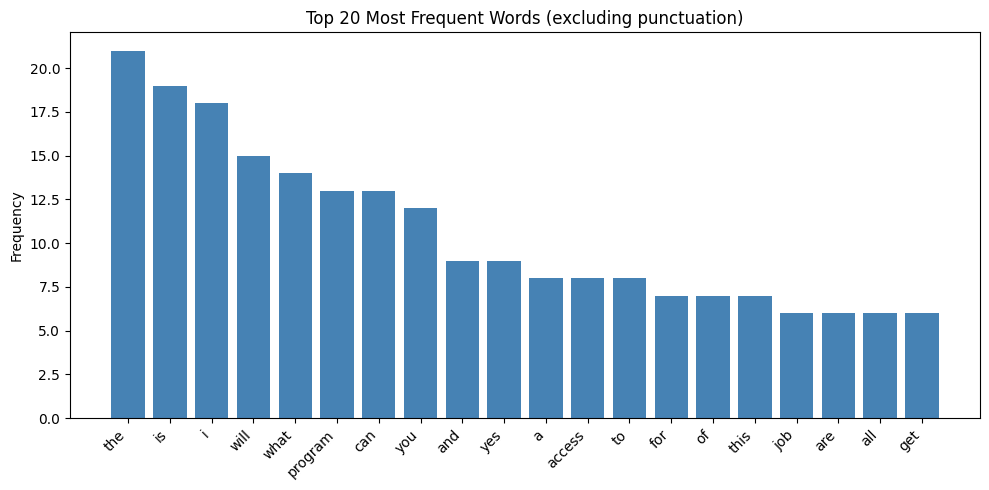

In [145]:
import string

word_only_tokens = [t for t in tokens if t not in string.punctuation]
word_freq = Counter(word_only_tokens)
top_words = word_freq.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='steelblue')
plt.title("Top 20 Most Frequent Words (excluding punctuation)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("assets/vocab_frequency.png", dpi=150, bbox_inches='tight')
plt.show()

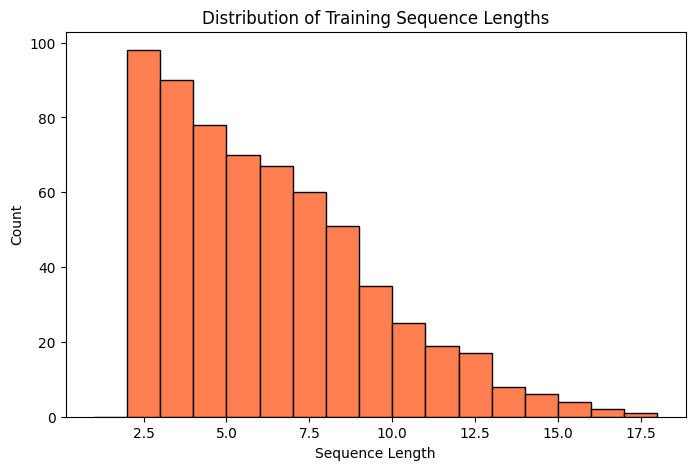

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(len_list, bins=range(1, max(len_list)+2), color='coral', edgecolor='black')
plt.title("Distribution of Training Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.savefig("assets/sequence_length_dist.png", dpi=150, bbox_inches='tight')
plt.show()

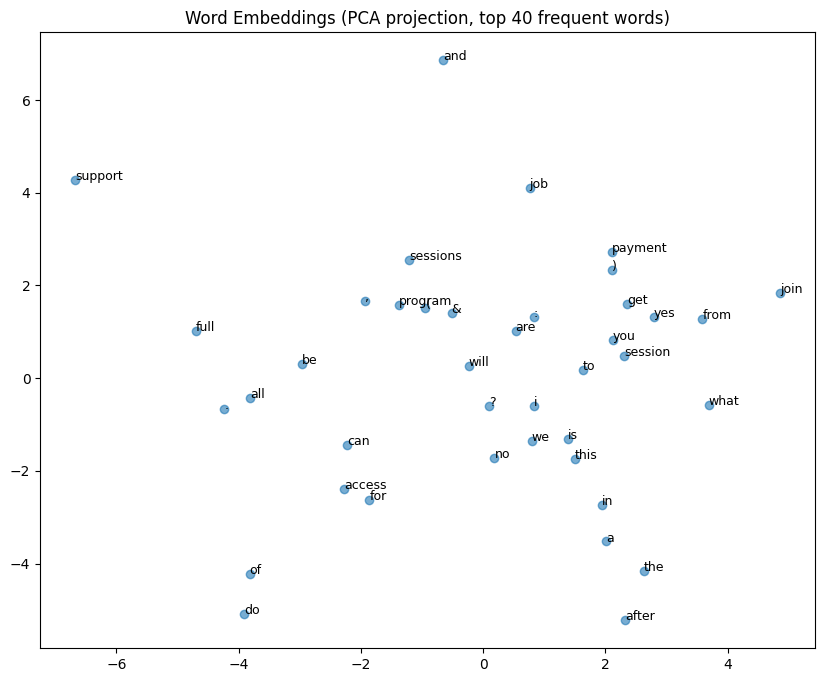

In [147]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

embeddings = model.embedding.weight.detach().cpu().numpy()

# Only plot the N most frequent words so the chart stays readable
top_n = 40
top_words_list = [w for w, _ in Counter(tokens).most_common(top_n)]
indices = [vocab[w] for w in top_words_list if w in vocab]

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings[indices])

plt.figure(figsize=(10, 8))
plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.6)
for i, word in enumerate(top_words_list):
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]), fontsize=9)
plt.title("Word Embeddings (PCA projection, top 40 frequent words)")
plt.savefig("assets/embeddings_pca.png", dpi=150, bbox_inches='tight')
plt.show()